# IMEN266 · Ch.4 · Practicum — Google PageRank is a Markov chain

*Source: class handout "Google PageRank — Markov Chains" (after Harchol-Balter,
Performance Modeling and Design of Computer Systems, 2013). This topic has
appeared on the midterm.*

**Plan** — 1 ranking by counting links (and why it fails) → 2 the random surfer:
rank $=$ stationary distribution → 3 dead ends & spider traps (ergodicity
violated) → 4 taxation (damping) restores ergodicity → 5 a bigger web, power
iteration, link spam → 6 exam-style drill.

**In-class version only:** cells marked `# TODO` are for you to complete; the
`check(...)` cell right after tells you whether your answer matches.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch04/notebooks/PageRank_practicum.ipynb`

In [1]:
# --- IMEN266 setup (Ch.4): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.dtmc import DTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_chain(P, states=None):
    """DTMC(P) if P is complete and valid; otherwise None (keeps 'Run all' alive)."""
    P = np.asarray(P, dtype=float)
    if np.isnan(P).any():
        print("[TODO] P still contains NaN entries - finish the TODO above."); return None
    try:
        return DTMC(P, states)
    except ValueError as e:
        print("[X  ] P is not a valid transition matrix:", e); return None

def check_rows(P):
    """Every row of a transition matrix must sum to 1 (and be nonnegative)."""
    P = np.asarray(P, dtype=float)
    err = None if np.isnan(P).any() else float(np.abs(P.sum(axis=1) - 1).max() + (P < 0).sum())
    return check("rows sum to 1, entries >= 0", err, 0.0, tol=1e-9)

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  DTMC imported.  Widgets available:", HAS_W)

Setup OK.  DTMC imported.  Widgets available: True


In [2]:
from imen266.pagerank import link_matrix, google_matrix, pagerank   # tiny helpers; read them!
import inspect; print(inspect.getsource(google_matrix))

def google_matrix(P: np.ndarray, beta: float = 0.85) -> np.ndarray:
    """G = beta * P + (1 - beta) * (1/n) 11^T  ("tax" (1-beta) redistributed
    equally to every page). For 0 < beta < 1, G is positive => ergodic."""
    n = P.shape[0]
    return beta * P + (1.0 - beta) / n * np.ones((n, n))



---
## 1 · Citation counting, and why it is gameable *(handout p. 3)*

First idea: rank a page by its number of incoming links. Problem: links are free.
Below, **T** is an ordinary page of a small honest web; a spammer creates 8 (then
16) worthless pages that all link to T — a *link farm*. In-degree crowns T
immediately; the random surfer is much less impressed, because the farm pages
have almost no rank to pass on (they only get the "tax" share of §4), and the
more fake pages there are, the thinner that share becomes.

target T = page 11: in-degree 2 (rank #5),  PageRank 0.074 (rank #6)
+ 8 fake pages: in-degree 10 -> rank #1 | PageRank 0.113 -> rank #3   (each fake page holds only 0.0075)
+16 fake pages: in-degree 18 -> rank #1 | PageRank 0.130 -> rank #3   (each fake page holds only 0.0054)


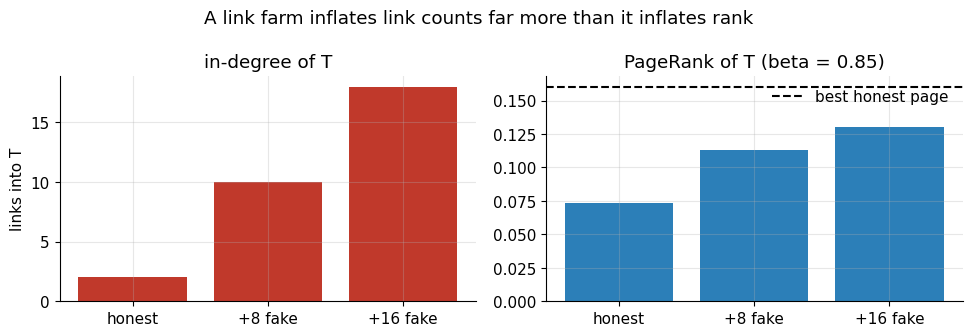

In [3]:
# a small honest web: 12 pages, each links to 2-3 random others
n_honest = 12
edges = []
for u in range(n_honest):
    for v in rng.choice([w for w in range(n_honest) if w != u], size=rng.integers(2, 4), replace=False):
        edges.append((u, int(v)))

def indeg(edges, n): return np.bincount([v for _, v in edges], minlength=n)
d0 = indeg(edges, n_honest); r0 = pagerank(link_matrix(edges, n_honest), beta=0.85)
T = int(np.argsort(r0)[n_honest // 2])                   # an ordinary (median) page
print(f"target T = page {T}: in-degree {d0[T]} (rank #{(d0 > d0[T]).sum()+1}),  PageRank {r0[T]:.3f} (rank #{(r0 > r0[T]).sum()+1})")

rows = []
for n_fake in [8, 16]:
    farm = range(n_honest, n_honest + n_fake)
    es = edges + [(f, T) for f in farm]                  # fake pages link ONLY to T
    d1 = indeg(es, n_honest + n_fake); r1 = pagerank(link_matrix(es, n_honest + n_fake), beta=0.85)
    rows.append((n_fake, d1[T], (d1[:n_honest] > d1[T]).sum() + 1, r1[T], (r1[:n_honest] > r1[T]).sum() + 1, r1[n_honest]))
    print(f"+{n_fake:2d} fake pages: in-degree {d1[T]:2d} -> rank #{rows[-1][2]} | PageRank {r1[T]:.3f} -> rank #{rows[-1][4]}   (each fake page holds only {r1[n_honest]:.4f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
labels = ["honest", "+8 fake", "+16 fake"]
ax[0].bar(labels, [d0[T], rows[0][1], rows[1][1]], color="#c0392b"); ax[0].set_title("in-degree of T"); ax[0].set_ylabel("links into T")
ax[1].bar(labels, [r0[T], rows[0][3], rows[1][3]], color="#2c7fb8"); ax[1].axhline(r0.max(), ls="--", c="k", label="best honest page"); ax[1].legend()
ax[1].set_title("PageRank of T (beta = 0.85)"); plt.suptitle("A link farm inflates link counts far more than it inflates rank"); plt.tight_layout(); plt.show()

**Think about it** — the farm still lifts T's PageRank a little. Where does that
rank come from, and why does going from 8 to 16 fake pages add so little?
(Hint: the tax in §4 gives *every* page, including fake ones, a share
$(1-\beta)/n$ — and $n$ grows with the farm.) Real search engines add many more
signals, but the Markov-chain core is exactly what follows.

---
## 2 · The random surfer: rank $=$ stationary distribution *(handout pp. 4–5)*

> **Rule:** if page $i$ has $k$ outgoing links, each link has probability $1/k$.
> Construct $P$. Solve $\pi=\pi P$.

A surfer who clicks a random link forever is a DTMC on the pages; the fraction
of time spent on page $j$ is $\pi_j$ — and that is the rank. The handout's
3-page web: $1\to1,\ 1\to2$ (½ each), $2\to1,\ 2\to3$ (½ each), $3\to2$ (1).
Handout answer: $\pi=(0.4,\,0.4,\,0.2)$.

[[0.5 0.5 0. ]
 [0.5 0.  0.5]
 [0.  1.  0. ]]
pi = [0.4 0.4 0.2]
3 states; 1 communicating class(es)
  ['page1', 'page2', 'page3']: recurrent, period 1
absorbing: none
ergodic: True


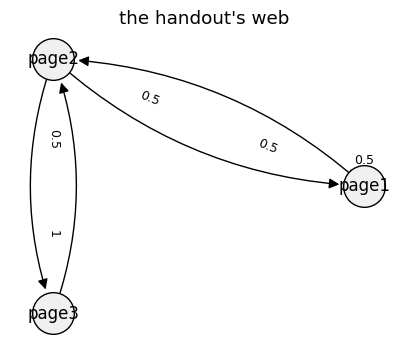

In [4]:
edges3 = [(0, 0), (0, 1), (1, 0), (1, 2), (2, 1)]      # pages 1,2,3 -> indices 0,1,2
P3 = link_matrix(edges3, 3)
surfer = DTMC(P3, ["page1", "page2", "page3"])
pi3 = surfer.stationary()
print(P3); print("pi =", pi3.round(4)); print(surfer.summary())
surfer.plot_transition_diagram(); plt.title("the handout's web"); plt.show()

In [5]:
check("pi_1", None if pi3 is None else pi3[0], 0.4, tol=1e-9)
check("pi_3", None if pi3 is None else pi3[2], 0.2, tol=1e-9)

[OK ] pi_1: got 0.4   (reference 0.4)
[OK ] pi_3: got 0.2   (reference 0.2)


True

fraction of time on each page: [0.405 0.398 0.197]   vs pi [0.4 0.4 0.2]


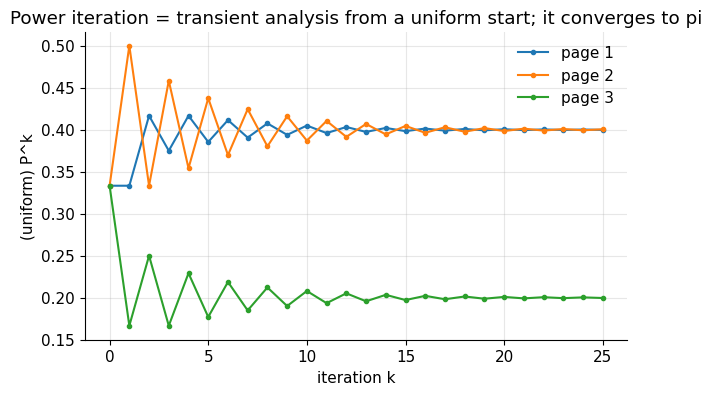

In [6]:
# --- Simulate a surfer for 100,000 clicks -------------------------------------------
if surfer is None:
    print("(finish TODO 1 first)")
else:
    clicks = surfer.sample_path(100_000, x0=0, rng=rng)
    print("fraction of time on each page:", surfer.occupancy(clicks).round(3), "  vs pi", pi3.round(3))
    # power iteration by hand: pi_{k+1} = pi_k P  (this is p_n = a P^n from CP4!)
    p = np.full(3, 1/3); hist = [p]
    for _ in range(25): p = p @ P3; hist.append(p)
    hist = np.array(hist)
    plt.figure()
    for j in range(3): plt.plot(hist[:, j], "o-", ms=3, label=f"page {j+1}")
    plt.xlabel("iteration k"); plt.ylabel("(uniform) P^k"); plt.legend()
    plt.title("Power iteration = transient analysis from a uniform start; it converges to pi"); plt.show()

**Think about it** — (i) Page 3 has *one* incoming link (from 2) and page 1 has
two (from itself and from 2), yet $\pi_1=\pi_2$. Explain with the balance
equation for page 2. (ii) The power iteration is literally CP4's $aP^n$. What
property of this 3-page chain makes it converge (check `surfer.summary()`)?

---
## 3 · Dead ends and spider traps: ergodicity violated *(handout p. 6)*

Replace the link $3\to2$ by a self-link $3\to3$: page 3 becomes a **spider trap**
(absorbing state). The surfer eventually enters it and never leaves:
$\pi=(0,0,1)$ — page 3 gets *all* the rank, which is absurd. Remove page 3's
links altogether and it is a **dead end**: the row of $P$ is all zeros, the
matrix is sub-stochastic, and the rank "leaks" out of the system.

spider trap:
3 states; 2 communicating class(es)
  ['page1', 'page2']: transient, period 1
  ['page3']: recurrent, period 1
absorbing: ['page3']
ergodic: False
pi = [0. 0. 1.]

dead end: row sums = [1. 1. 0.]


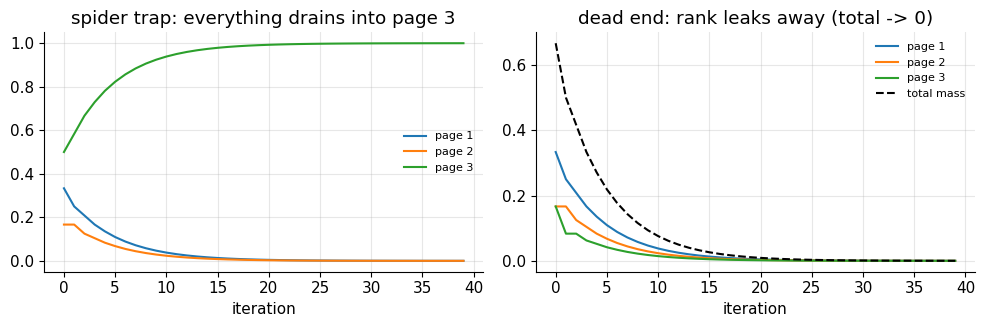

In [7]:
edges_trap = [(0, 0), (0, 1), (1, 0), (1, 2), (2, 2)]
P_trap = link_matrix(edges_trap, 3)
trap = DTMC(P_trap, ["page1", "page2", "page3"])
print("spider trap:"); print(trap.summary()); print("pi =", trap.stationary().round(3))

edges_dead = [(0, 0), (0, 1), (1, 0), (1, 2)]
P_dead = link_matrix(edges_dead, 3, dangling="keep")             # row 3 stays zero: sub-stochastic
print("\ndead end: row sums =", P_dead.sum(axis=1))

p_t, p_d = np.full(3, 1/3), np.full(3, 1/3); mass_t, mass_d = [], []
for k in range(40):
    p_t = p_t @ P_trap; p_d = p_d @ P_dead
    mass_t.append(p_t.copy()); mass_d.append(p_d.copy())
mass_t, mass_d = np.array(mass_t), np.array(mass_d)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for j in range(3): ax[0].plot(mass_t[:, j], label=f"page {j+1}"); ax[1].plot(mass_d[:, j], label=f"page {j+1}")
ax[1].plot(mass_d.sum(axis=1), "k--", label="total mass")
ax[0].set_title("spider trap: everything drains into page 3"); ax[1].set_title("dead end: rank leaks away (total -> 0)")
for a in ax: a.set_xlabel("iteration"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Think about it** — Which of the three ergodicity conditions (irreducible,
positive recurrent, aperiodic) does the spider trap violate? Which does a
2-page web with links $1\to2$, $2\to1$ only violate — and what does power
iteration do there?

---
## 4 · Taxation *(handout p. 7)*

> Collect a tax $(1-\beta)$ from every page and distribute it equally to every node.

With tax rate 30 % ($\beta=0.7$): the surfer follows a link w.p. $0.7$ and jumps
to a uniformly random page w.p. $0.3$. The new transition matrix
$$G=\beta P+\frac{1-\beta}{n}\mathbf 1\mathbf 1^{\!\top}$$
is **strictly positive**, hence irreducible and aperiodic: $\pi$ is unique and
power iteration converges from any start (Companion Proof 7). For the spider-trap
web the handout gets $\pi=(0.26,\,0.19,\,0.55)$: page 3 still wins, but no
longer takes everything.

In [8]:
beta = 0.7
G = beta * P_trap + (1 - beta) / 3 * np.ones((3, 3))
print("G =\n", G.round(3), "\nrow sums:", G.sum(axis=1))

pi_G = np.full(3, 1/3)
for _ in range(200):                                   # power iteration
    pi_G = pi_G @ G
print("pi (30% tax) =", pi_G.round(4))
print("library      =", pagerank(P_trap, beta=0.7).round(4))

G =
 [[0.45 0.45 0.1 ]
 [0.45 0.1  0.45]
 [0.1  0.1  0.8 ]] 
row sums: [1. 1. 1.]
pi (30% tax) = [0.2559 0.1896 0.5545]
library      = [0.2559 0.1896 0.5545]


In [9]:
check("G[3,3] = 0.7*1 + 0.1", None if np.isnan(G).any() else G[2, 2], 0.8, tol=1e-9)
check("pi_3 after taxation", None if (pi_G is Ellipsis or np.isnan(np.asarray(pi_G, float)).any()) else pi_G[2], 0.5545, tol=1e-3)

[OK ] G[3,3] = 0.7*1 + 0.1: got 0.8   (reference 0.8)
[OK ] pi_3 after taxation: got 0.554502   (reference 0.5545)


True

In [10]:
def tax_exp(beta=0.7):
    G = google_matrix(P_trap, beta)
    p = np.full(3, 1/3); hist = [p]
    for _ in range(30): p = p @ G; hist.append(p)
    hist = np.array(hist)
    plt.figure()
    for j in range(3): plt.plot(hist[:, j], "o-", ms=3, label=f"page {j+1}")
    lam = np.sort(np.abs(np.linalg.eigvals(G)))[-2]
    plt.title(f"beta = {beta}:  pi = {np.round(hist[-1], 3)};   |2nd eigenvalue| = {lam:.2f} <= beta"); plt.xlabel("iteration"); plt.legend(); plt.show()

show(tax_exp, beta=FloatSlider(min=0, max=1, step=.05, value=.7) if HAS_W else .7)

interactive(children=(FloatSlider(value=0.7, description='beta', max=1.0, step=0.05), Output()), _dom_classes=…

**Think about it** — (i) $\beta=0$ gives $\pi$ uniform, $\beta=1$ gives the
trap. Google's classic choice is $\beta=0.85$. What is traded off? (ii) The
title reports the second-largest eigenvalue modulus: it never exceeds $\beta$.
Why does that make power iteration fast *regardless of the web's structure*?

---
## 5 · A bigger web: power iteration at scale, and link spam

200 pages, random links. Compare (a) in-degree vs PageRank, (b) power iteration
vs solving the linear system, (c) how a link farm moves a page's rank for
different $\beta$.

power iteration: 52 iterations;  max |pi_pow - pi_lin| = 4.06e-14


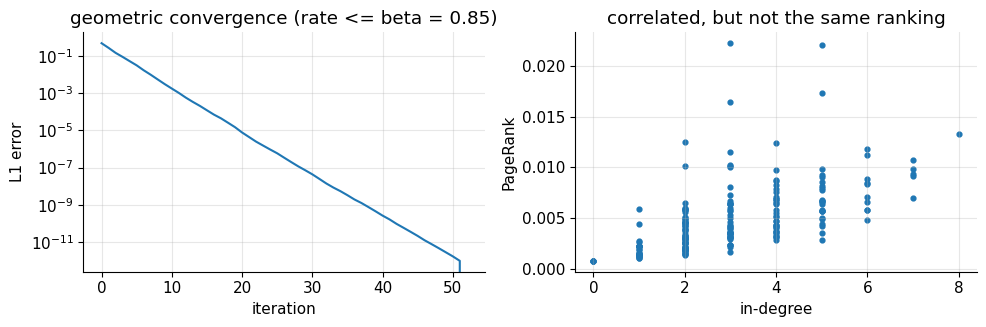

In [11]:
n = 200
edges = [(u, int(v)) for u in range(n) for v in rng.choice(n, size=rng.integers(1, 6), replace=False) if v != u]
P = link_matrix(edges, n)
pi_pow, hist = pagerank(P, beta=0.85, history=True)
pi_lin = DTMC(google_matrix(P, 0.85)).stationary()
print(f"power iteration: {len(hist)-1} iterations;  max |pi_pow - pi_lin| = {np.abs(pi_pow - pi_lin).max():.2e}")
err = [np.abs(h - pi_pow).sum() for h in hist]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].semilogy(err); ax[0].set_xlabel("iteration"); ax[0].set_ylabel("L1 error"); ax[0].set_title("geometric convergence (rate <= beta = 0.85)")
ax[1].scatter(indeg(edges, n), pi_pow, s=12); ax[1].set_xlabel("in-degree"); ax[1].set_ylabel("PageRank")
ax[1].set_title("correlated, but not the same ranking"); plt.tight_layout(); plt.show()

In [12]:
def spam_exp(n_fake=20, beta=0.85):
    target = int(np.argsort(pi_pow)[n // 2])                    # a median page
    spam = edges + [(n + f, target) for f in range(n_fake)] + [(target, n + f) for f in range(n_fake)]  # farm links to T, T links back
    r = pagerank(link_matrix(spam, n + n_fake), beta=beta)
    base = pagerank(P, beta=beta)
    rk0 = int((base > base[target]).sum()) + 1; rk1 = int((r[:n] > r[target]).sum()) + 1
    plt.figure(); plt.bar(["before", "after farm"], [base[target], r[target]])
    plt.title(f"target page: rank #{rk0} -> #{rk1} of {n} honest pages  (beta = {beta}, {n_fake} fake pages)"); plt.ylabel("PageRank"); plt.show()

show(spam_exp,
     n_fake=IntSlider(min=0, max=100, step=5, value=20) if HAS_W else 20,
     beta=FloatSlider(min=.5, max=.99, step=.01, value=.85) if HAS_W else .85)

interactive(children=(IntSlider(value=20, description='n_fake', step=5), FloatSlider(value=0.85, description='…

**Think about it** — With the farm linking to T *and* T linking back to the
farm, the farm recycles the tax it receives. Explain in Markov-chain terms
(where does the surfer spend time?) why a *closed* farm is more effective than
one-way links — and why a larger tax (smaller $\beta$) blunts it.

---
## 6 · Exam-style drill

A web has 4 pages with links $1\to2$, $1\to3$, $2\to3$, $3\to1$, $4\to1$, $4\to3$.
With $\beta=0.8$:
(a) write $P$ and $G$; (b) do **one** power-iteration step from the uniform start
by hand; (c) compute $\pi$ exactly. Then confirm below.

In [13]:
edges4 = [(0, 1), (0, 2), (1, 2), (2, 0), (3, 0), (3, 2)]
P4 = link_matrix(edges4, 4); G4 = google_matrix(P4, 0.8)
one_step = np.full(4, 1/4) @ G4
pi4 = DTMC(G4).stationary()
print("P =\n", P4.round(3)); print("one step from uniform:", one_step.round(4)); print("pi =", pi4.round(4))

P =
 [[0.  0.5 0.5 0. ]
 [0.  0.  1.  0. ]
 [1.  0.  0.  0. ]
 [0.5 0.  0.5 0. ]]
one step from uniform: [0.35 0.15 0.45 0.05]
pi = [0.3726 0.1991 0.3783 0.05  ]


In [14]:
_G = google_matrix(link_matrix([(0, 1), (0, 2), (1, 2), (2, 0), (3, 0), (3, 2)], 4), 0.8)
check("one step, page 3", None if one_step is Ellipsis else one_step[2], float((np.full(4, .25) @ _G)[2]), tol=1e-9)
check("pi, page 4 (nobody links to it)", None if pi4 is Ellipsis else pi4[3], float(DTMC(_G).stationary()[3]), tol=1e-9)

[OK ] one step, page 3: got 0.45   (reference 0.45)
[OK ] pi, page 4 (nobody links to it): got 0.05   (reference 0.05)


True

**Think about it** — page 4 has no incoming links, yet $\pi_4=(1-\beta)/n$
exactly. Prove it from $\pi=\pi G$. *(This is the kind of one-line derivation
the midterm has asked for.)*

### Drill B — a dead end (midterm-style)

Three sites: **A** links to A, B and C; **B** has no outbound links; **C** links
to A and B. Rank them with PageRank, "appropriately assigning the transition
probabilities and incorporating taxation to ensure ergodicity" — i.e. repair
the dead end first (`link_matrix` gives a dead end a uniform row), then tax
with $\beta=0.85$. Before running: which two sites will tie, and why?

In [15]:
edgesB = [(0, 0), (0, 1), (0, 2), (2, 0), (2, 1)]          # A=0, B=1, C=2; B is a dead end
PB = link_matrix(edgesB, 3)                                     # dead-end row -> uniform
piB = pagerank(PB, beta=0.85)
print("P (repaired) =\n", PB.round(3)); print("pi =", piB.round(4), " ranking:", ["ABC"[i] for i in np.argsort(-piB)])

P (repaired) =
 [[0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.5   0.5   0.   ]]
pi = [0.3701 0.3701 0.2597]  ranking: ['A', 'B', 'C']


In [16]:
_PB = link_matrix([(0, 0), (0, 1), (0, 2), (2, 0), (2, 1)], 3)
check("dead-end row is uniform", None if PB is Ellipsis else PB[1].sum(), 1.0, tol=1e-9)
check("pi_C", None if piB is Ellipsis else piB[2], float(pagerank(_PB, beta=0.85)[2]), tol=1e-9)

[OK ] dead-end row is uniform: got 1   (reference 1)
[OK ] pi_C: got 0.25974   (reference 0.25974)


True

**Why the tie.** After the repair, A and B have identical *in-link* profiles
(A sends 1/3 to each, B sends 1/3 to each, C sends 1/2 to each), so the columns
of $G$ for A and B coincide and $\pi_A=\pi_B$; C gets the rest.

---
## Wrap-up

| idea | Markov-chain name | where |
|---|---|---|
| rank $=$ long-run fraction of surfer time | stationary distribution $\pi=\pi P$ | §2 |
| spider trap / dead end | absorbing state / sub-stochastic $P$ (not ergodic) | §3 |
| taxation with rate $1-\beta$ | $G=\beta P+\frac{1-\beta}{n}\mathbf{1}\mathbf{1}^{\!\top}$, positive ⇒ ergodic | §4, Companion Proof 7 |
| power iteration | transient analysis $aG^k$, converges at rate $\le\beta$ | §2, §5 |